In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [ ]:
image_dir = "/content/drive/MyDrive/Dataset/"   # main folder

img_height = 128
img_width = 128
batch_size = 16
epochs = 20

In [ ]:
def load_all_good_images(base_dir, img_size=(128,128)):
    images = []

    # Loop through all type folders
    for folder in os.listdir(base_dir):
        type_path = os.path.join(base_dir, folder)

        if os.path.isdir(type_path):
            good_path = os.path.join(type_path, "train", "good")

            if os.path.exists(good_path):
                print(f"Loading from: {good_path}")

                for img_file in tqdm(os.listdir(good_path), desc=f"{folder}"):
                    img_path = os.path.join(good_path, img_file)

                    img = cv2.imread(img_path)
                    if img is None:
                        continue

                    img = cv2.resize(img, img_size)
                    img = img.astype(np.float32) / 255.0

                    images.append(img)

    return np.array(images)

In [ ]:
X = load_all_good_images(image_dir, img_size=(img_height, img_width))

print("Total images loaded:", X.shape)

Loading from: /content/drive/MyDrive/Dataset/type9cam2/train/good


type9cam2: 100%|██████████| 721/721 [00:34<00:00, 21.10it/s] 


Loading from: /content/drive/MyDrive/Dataset/type7cam2/train/good


type7cam2: 100%|██████████| 711/711 [00:25<00:00, 27.42it/s] 


Loading from: /content/drive/MyDrive/Dataset/type4cam2/train/good


...

Loading from: /content/drive/MyDrive/Dataset/type10cam2/train/good


type10cam2: 100%|██████████| 717/717 [00:23<00:00, 30.98it/s] 


Loading from: /content/drive/MyDrive/Dataset/type1cam1/train/good


type1cam1: 100%|██████████| 272/272 [00:08<00:00, 32.25it/s] 


Total images loaded: (4391, 128, 128, 3)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)

np.random.shuffle(X_train)

In [ ]:
def build_unet(input_shape=(128, 128, 3)):
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D()(c3)

    # Bottleneck
    b = Conv2D(256, 3, activation='relu', padding='same')(p3)
    b = Conv2D(256, 3, activation='relu', padding='same')(b)

    # Decoder
    u1 = Conv2DTranspose(128, 2, strides=2, padding='same')(b)
    u1 = Concatenate()([u1, c3])
    c4 = Conv2D(128, 3, activation='relu', padding='same')(u1)
    c4 = Conv2D(128, 3, activation='relu', padding='same')(c4)

    u2 = Conv2DTranspose(64, 2, strides=2, padding='same')(c4)
    u2 = Concatenate()([u2, c2])
    c5 = Conv2D(64, 3, activation='relu', padding='same')(u2)
    c5 = Conv2D(64, 3, activation='relu', padding='same')(c5)

    u3 = Conv2DTranspose(32, 2, strides=2, padding='same')(c5)
    u3 = Concatenate()([u3, c1])
    c6 = Conv2D(32, 3, activation='relu', padding='same')(u3)
    c6 = Conv2D(32, 3, activation='relu', padding='same')(c6)

    outputs = Conv2D(3, 1, activation='sigmoid')(c6)

    return Model(inputs, outputs)

In [ ]:
def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

def combined_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    return mse + ssim_loss(y_true, y_pred)

# model = build_unet((img_height, img_width, 3))

# model.compile(
#     optimizer=Adam(1e-4),
#     loss=combined_loss
# )

# model.summary()

In [ ]:
# history = model.fit(
#     X_train, X_train,
#     validation_data=(X_val, X_val),
#     epochs=epochs,
#     batch_size=batch_size
# )

Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - loss: 0.3692 - val_loss: 0.0687
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - loss: 0.0420 - val_loss: 0.0266
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - loss: 0.0209 - val_loss: 0.0177
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - loss: 0.0156 - val_loss: 0.0144
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 17s 76ms/step - loss: 0.0130 - val_loss: 0.0128
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 17s 78ms/step - loss: 0.0116 - val_loss: 0.0111
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 18s 80ms/step - loss: 0.0102 - val_loss: 0.0099
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 18s 81ms/step - loss: 0.0092 - val_loss: 0.0089
Epoch 9/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 17s 78ms/step - loss: 0.0084 - val_loss: 0.0083
Epoch 10/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - loss: 0.0077 - val_loss: 0.0075
Epoch 11/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 17s 78ms/step - loss: 0.0071 - val_loss: 0.0069
Epoch 12/20
220/220 ━━━━━━━━━

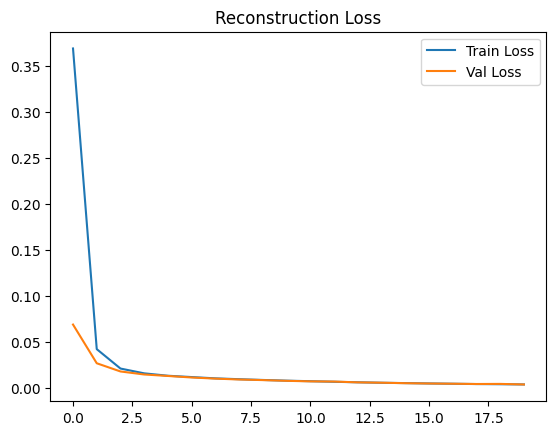

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Reconstruction Loss')
plt.legend()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/resunet_model.h5",
    custom_objects={
        "combined_loss": combined_loss,
        "ssim_loss": ssim_loss
    }
)

In [ ]:
val_errors = []

crop = 10   # ignore border pixels

# Iterate directly over the validation image data from X_val
# X_val already contains normalized images
for img_data_single in X_val[:100]:
    img_input = np.expand_dims(img_data_single, axis=0)

    recon = model.predict(img_input)[0]

    # ✅ Pixel-wise error
    error_map = np.mean((img_data_single - recon) ** 2, axis=2) # Compare original image data with reconstruction

    # ✅ Smooth error (reduce noise)
    error_map = cv2.GaussianBlur(error_map, (5,5), 0)

    # ✅ Remove borders
    h, w = error_map.shape
    cropped_error = error_map[crop:h-crop, crop:w-crop]

    # ✅ Top-K scoring (more robust)
    flat = cropped_error.flatten()
    score = np.mean(np.sort(flat)[-300:])   # top 300 pixels

    val_errors.append(score)

# ✅ Final threshold
threshold = np.mean(val_errors) + 2 * np.std(val_errors)

print("Threshold:", threshold)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━

In [1]:
from google.colab import files

uploaded = files.upload()

crop = 10   # ignore edges

for filename in uploaded.keys():
    img = cv2.imread(filename)
    original_size = img.shape[:2]

    img_resized = cv2.resize(img, (img_width, img_height))
    img_norm = img_resized / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    recon = model.predict(img_input)[0]

    # ✅ Pixel-wise MSE error
    error_map = np.mean((img_norm - recon) ** 2, axis=2)

    # ✅ Smooth error (removes texture noise)
    error_map = cv2.GaussianBlur(error_map, (5,5), 0)

    # ✅ Remove borders
    h, w = error_map.shape
    cropped_error = error_map[crop:h-crop, crop:w-crop]

    # ✅ Resize for visualization
    error_map_resized = cv2.resize(error_map, (original_size[1], original_size[0]))

    # ✅ Pixel threshold (ONLY on cropped region)
    #pixel_threshold = np.percentile(cropped_error, 99)

    # ✅ Mask creation

    # ✅ Normalize error map (0 → 1)
    norm_error = (error_map - error_map.min()) / (error_map.max() - error_map.min() + 1e-8)

    # ✅ Threshold based on intensity (like red region)
    pixel_threshold = 0.2   # you can tune: 0.3–0.6

    mask = (norm_error > pixel_threshold).astype(np.uint8) * 255
    # mask = np.zeros_like(error_map, dtype=np.uint8)
    # mask[crop:h-crop, crop:w-crop] = (cropped_error > pixel_threshold).astype(np.uint8)

    # ✅ Resize mask
    # mask = cv2.resize(mask, (original_size[1], original_size[0])) * 255

    # 🔥 Morphological cleaning
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # ✅ Better scoring (Top-K on cropped region)
    flat = cropped_error.flatten()
    score = np.mean(np.sort(flat)[-5:])

    # ✅ Classification
    label = "ANOMALY" if score > threshold else "NORMAL"

    # 🔥 Normalize error map for display
    vis_error = (error_map - error_map.min()) / (error_map.max() - error_map.min() + 1e-8)

    # Plot
    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(recon.astype(np.float32)) # Cast recon to float32
    plt.title("Reconstruction")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(vis_error.astype(np.float32), cmap='hot') # Cast vis_error to float32
    plt.title("Error Map")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Mask ({label})")
    plt.axis("off")

    plt.show()

    print("Score:", score)
    print("Prediction:", label)


ModuleNotFoundError: No module named 'google.colab'